# IPL PREDICTION MODEL

##### INITIAL SETUP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
matches = pd.read_csv('/content/drive/MyDrive/matches.csv')
deliveries = pd.read_csv('/content/drive/MyDrive/deliveries.csv')

##### OVERVIEW OF matches.csv

In [3]:
matches.sample(5)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1045,1426260,2024,Chennai,2024-04-08,League,RA Jadeja,"MA Chidambaram Stadium, Chepauk, Chennai",Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,field,Chennai Super Kings,wickets,7.0,138.0,20.0,N,NaN,AK Chaudhary,MV Saidharshan Kumar
799,1216541,2020/21,Abu Dhabi,2020-10-25,League,BA Stokes,Sheikh Zayed Stadium,Mumbai Indians,Rajasthan Royals,Mumbai Indians,bat,Rajasthan Royals,wickets,8.0,196.0,20.0,N,NaN,UV Gandhe,VK Sharma
580,1082594,2017,Indore,2017-04-08,League,GJ Maxwell,Holkar Cricket Stadium,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,Kings XI Punjab,wickets,6.0,164.0,20.0,N,NaN,AK Chaudhary,C Shamshuddin
1008,1359533,2023,Delhi,2023-05-13,League,P Simran Singh,"Arun Jaitley Stadium, Delhi",Punjab Kings,Delhi Capitals,Delhi Capitals,field,Punjab Kings,runs,31.0,168.0,20.0,N,NaN,CB Gaffaney,NA Patwardhan
268,548327,2012,Bangalore,2012-04-17,League,CH Gayle,M Chinnaswamy Stadium,Royal Challengers Bangalore,Pune Warriors,Pune Warriors,bat,Royal Challengers Bangalore,wickets,6.0,183.0,20.0,N,NaN,S Asnani,S Das


In [4]:
matches.shape

(1095, 20)

In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
matches['method'].value_counts()

,count
method,
D/L,21


this method column indicates the use of Duckworth–Lewis–Stern (DLS) method, which is used to give a winner for an unfinished match.

In [7]:
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [8]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [9]:
matches.duplicated().sum()

np.int64(0)

<Axes: >

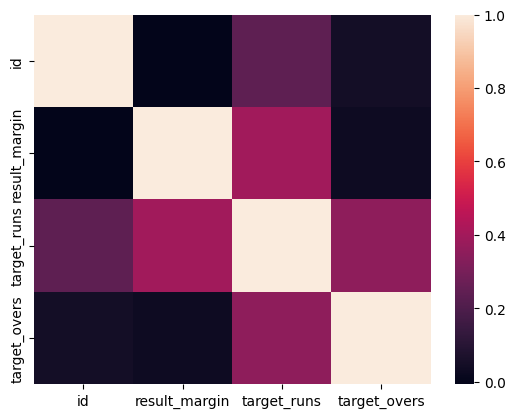

In [10]:
sns.heatmap(matches.corr(numeric_only=True))

##### OVERVIEW OF deliveries.csv

In [11]:
deliveries.sample(10)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
150079,1082649,1,Kolkata Knight Riders,Mumbai Indians,12,2,SA Yadav,KH Pandya,IR Jaggi,4,0,4,NaN,0,NaN,NaN,NaN
1077,335986,2,Kolkata Knight Riders,Deccan Chargers,3,4,SC Ganguly,RP Singh,WP Saha,1,0,1,NaN,0,NaN,NaN,NaN
124356,980917,1,Mumbai Indians,Gujarat Lions,4,4,JC Buttler,P Kumar,PA Patel,4,0,4,NaN,0,NaN,NaN,NaN
109216,829707,2,Delhi Daredevils,Chennai Super Kings,1,3,MA Agarwal,MM Sharma,CM Gautam,1,0,1,NaN,0,NaN,NaN,NaN
57773,501268,2,Chennai Super Kings,Royal Challengers Bangalore,4,2,SK Raina,Z Khan,S Badrinath,0,0,0,NaN,0,NaN,NaN,NaN
23659,392225,2,Mumbai Indians,Rajasthan Royals,18,3,AM Nayar,J Botha,Harbhajan Singh,6,0,6,NaN,0,NaN,NaN,NaN
182597,1216506,2,Chennai Super Kings,Kings XI Punjab,6,1,F du Plessis,M Ashwin,RD Gaikwad,1,0,1,NaN,0,NaN,NaN,NaN
143126,1082618,1,Rising Pune Supergiant,Mumbai Indians,15,1,MS Dhoni,MJ McClenaghan,BA Stokes,1,0,1,NaN,0,NaN,NaN,NaN
33737,419133,1,Royal Challengers Bangalore,Chennai Super Kings,10,6,V Kohli,SB Jakati,JH Kallis,1,0,1,NaN,0,NaN,NaN,NaN
54281,501252,2,Royal Challengers Bangalore,Rajasthan Royals,3,5,CH Gayle,J Botha,TM Dilshan,0,0,0,NaN,0,NaN,NaN,NaN


In [12]:
deliveries.shape

(260920, 17)

In [13]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [14]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [15]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [16]:
deliveries.duplicated().sum()

np.int64(0)

<Axes: >

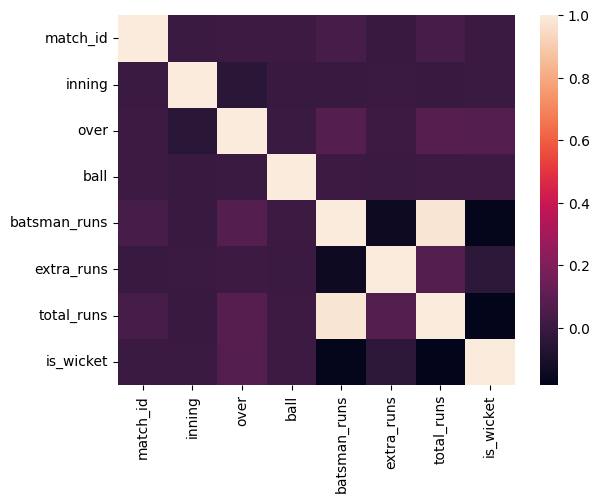

In [17]:
sns.heatmap(deliveries.corr(numeric_only=True))

##### Data Cleaning

###### Cleaning matches.csv

In [18]:
matches['venue'].nunique()

58

In [19]:
matches['venue'].value_counts().sort_index()

,count
venue,
Arun Jaitley Stadium,14
"Arun Jaitley Stadium, Delhi",16
Barabati Stadium,7
"Barsapara Cricket Stadium, Guwahati",3
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",14
Brabourne Stadium,10
"Brabourne Stadium, Mumbai",17
Buffalo Park,3
De Beers Diamond Oval,3


In [20]:
matches['team1'].value_counts().sort_index()

,count
team1,
Chennai Super Kings,128
Deccan Chargers,39
Delhi Capitals,41
Delhi Daredevils,85
Gujarat Lions,16
Gujarat Titans,21
Kings XI Punjab,92
Kochi Tuskers Kerala,7
Kolkata Knight Riders,121


In [21]:
TEAM_MAP = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
}
VENUE_MAP = {
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Sardar Patel Stadium": "Narendra Modi Stadium",
    "Punjab Cricket Association Stadium": "Punjab Cricket Association IS Bindra Stadium",
    "Zayed Cricket Stadium": "Sheikh Zayed Stadium",
    "Subrata Roy Sahara Stadium": "Maharashtra Cricket Association Stadium",
}


In [23]:
m = pd.read_csv("/content/drive/MyDrive/matches.csv")
m = m[m["result"] != "no result"].copy()          # drops the 5 null-winner matches


In [24]:
m["date"] = pd.to_datetime(m["date"])
m["year"] = m["date"].dt.year                      # use this for the time split

In [25]:
for c in ["team1", "team2", "toss_winner", "winner"]:
    m[c] = m[c].str.strip().replace(TEAM_MAP)

# "Eden Gardens, Kolkata" -> "Eden Gardens", then fix the remaining aliases
m["venue"] = m["venue"].str.split(",").str[0].str.strip().replace(VENUE_MAP)

m["team1_won"] = (m["winner"] == m["team1"]).astype(int)   # target

m = (m[["id", "date", "year", "match_type", "venue", "team1", "team2",
        "toss_winner", "toss_decision", "team1_won"]]
       .sort_values("date").reset_index(drop=True))

In [26]:
# checks
print(m.shape, m.isnull().sum().sum())
print(sorted(set(m.team1) | set(m.team2)))
print(m["venue"].value_counts())

(1090, 10) 0
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
venue
Wankhede Stadium                                                118
Eden Gardens                                                     93
M Chinnaswamy Stadium                                            91
Arun Jaitley Stadium                                             89
MA Chidambaram Stadium                                           85
Rajiv Gandhi International Stadium                               77
Punjab Cricket Association IS Bindra Stadium                     61
Sawai Mansingh Stadium                                           57
Maharashtra Cricket Association Stadium                          51
Dubai International Cricket Stadium              

In [27]:
m['venue'].nunique()

36

###### Cleaning deliveries.csv

In [29]:
d = pd.read_csv("/content/drive/MyDrive/deliveries.csv")

d = d[d["match_id"].isin(m["id"])]        # drop the no-result matches
d = d[d["inning"] <= 2].copy()            # innings 3-6 are super overs; keep them out of ratings

In [30]:
for c in ["batting_team", "bowling_team"]:
    d[c] = d[c].str.strip().replace(TEAM_MAP)
for c in ["batter", "bowler", "non_striker"]:
    d[c] = d[c].str.strip()

In [31]:
d["extras_type"] = d["extras_type"].fillna("none")   # NaN here just means no extra

In [32]:
# helper columns for player ratings
d["balls_faced"] = (d["extras_type"] != "wides").astype(int)               # wides aren't faced
d["legal_ball"] = (~d["extras_type"].isin(["wides", "noballs"])).astype(int)
charged = d["extras_type"].isin(["wides", "noballs"])                      # byes/legbyes aren't the bowler's
d["bowler_runs"] = d["batsman_runs"] + d["extra_runs"].where(charged, 0)
not_bowler = ["run out", "retired hurt", "retired out", "obstructing the field"]
d["bowler_wicket"] = ((d["is_wicket"] == 1) & ~d["dismissal_kind"].isin(not_bowler)).astype(int)


In [33]:
d = d.drop(columns=["fielder"])

In [34]:
# checks
print(d.shape, d["match_id"].nunique(), m.shape[0])   # the last two should match
print(d["batter"].nunique(), d["bowler"].nunique())

(260269, 20) 1090 1090
673 529


In [35]:
from collections import defaultdict, deque

K = 5  # smoothing: pulls small samples towards 0.5
def smooth(w, n): return (w + 0.5 * K) / (n + K)

form = defaultdict(lambda: deque(maxlen=5))   # last 5 results per team
h2h  = defaultdict(lambda: [0, 0])            # sorted team pair -> [wins of key[0], matches]
vrec = defaultdict(lambda: [0, 0])            # (team, venue) -> [wins, matches]

feat = []
for r in m.itertuples():
    t1, t2, v, t1w = r.team1, r.team2, r.venue, r.team1_won
    key = tuple(sorted([t1, t2]))
    w, n = h2h[key]

    feat.append({
        "id": r.id,
        "t1_form": smooth(sum(form[t1]), len(form[t1])),
        "t2_form": smooth(sum(form[t2]), len(form[t2])),
        "h2h_t1": smooth(w if key[0] == t1 else n - w, n),
        "t1_venue_wr": smooth(*vrec[(t1, v)]),
        "t2_venue_wr": smooth(*vrec[(t2, v)]),
    })

    # update history only AFTER recording the features
    form[t1].append(t1w);  form[t2].append(1 - t1w)
    h2h[key][1] += 1
    if (key[0] == t1) == bool(t1w): h2h[key][0] += 1
    vrec[(t1, v)][0] += t1w;      vrec[(t1, v)][1] += 1
    vrec[(t2, v)][0] += 1 - t1w;  vrec[(t2, v)][1] += 1

X = m.merge(pd.DataFrame(feat), on="id")
X["toss_winner_is_t1"] = (X["toss_winner"] == X["team1"]).astype(int)
X["toss_bat"]          = (X["toss_decision"] == "bat").astype(int)
X["t1_bats_first"]     = (X["toss_winner_is_t1"] == X["toss_bat"]).astype(int)

In [36]:
X.head()

,id,date,year,match_type,venue,team1,team2,toss_winner,toss_decision,team1_won,t1_form,t2_form,h2h_t1,t1_venue_wr,t2_venue_wr,toss_winner_is_t1,toss_bat,t1_bats_first
0,335982,2008-04-18,2008,League,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,0,0.500000,0.500000,0.5,0.5,0.5,1,0,0
1,335983,2008-04-19,2008,League,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,0,0.500000,0.500000,0.5,0.5,0.5,0,1,0
2,335984,2008-04-19,2008,League,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,1,0.500000,0.500000,0.5,0.5,0.5,0,1,0
3,335985,2008-04-20,2008,League,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,0,0.500000,0.416667,0.5,0.5,0.5,1,1,1
4,335986,2008-04-20,2008,League,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,1,0.583333,0.500000,0.5,0.5,0.5,0,1,0


In [37]:
import joblib
import pandas as pd
from collections import defaultdict, deque

#  A. team features (history BEFORE each match only)
SMOOTH_K = 5
def smooth(w, n): return (w + 0.5 * SMOOTH_K) / (n + SMOOTH_K)

form = defaultdict(lambda: deque(maxlen=5))   # team -> last 5 results
h2h  = defaultdict(lambda: [0, 0])            # sorted pair -> [wins of key[0], matches]
vrec = defaultdict(lambda: [0, 0])            # (team, venue) -> [wins, matches]

rows = []
for r in m.itertuples():
    t1, t2, v, t1w = r.team1, r.team2, r.venue, int(r.team1_won)
    key = tuple(sorted([t1, t2]))
    w, n = h2h[key]
    rows.append({
        "id": r.id,
        "t1_form": smooth(sum(form[t1]), len(form[t1])),
        "t2_form": smooth(sum(form[t2]), len(form[t2])),
        "h2h_t1": smooth(w if key[0] == t1 else n - w, n),
        "t1_venue_wr": smooth(*vrec[(t1, v)]),
        "t2_venue_wr": smooth(*vrec[(t2, v)]),
    })
    # update history only AFTER recording the features
    form[t1].append(t1w); form[t2].append(1 - t1w)
    h2h[key][1] += 1
    if (key[0] == t1) == bool(t1w): h2h[key][0] += 1
    vrec[(t1, v)][0] += t1w;     vrec[(t1, v)][1] += 1
    vrec[(t2, v)][0] += 1 - t1w; vrec[(t2, v)][1] += 1

X = m.merge(pd.DataFrame(rows), on="id")
X["toss_winner_is_t1"] = (X["toss_winner"] == X["team1"]).astype(int)
X["toss_bat"]          = (X["toss_decision"] == "bat").astype(int)
X["t1_bats_first"]     = (X["toss_winner_is_t1"] == X["toss_bat"]).astype(int)
X["venue_model"] = X["venue"].where(X["venue"].map(X["venue"].value_counts()) >= 10, "Other")

#  B. player value per match (batting and bowling on the same scale)
bat = (d.groupby(["match_id", "batter", "batting_team"])
         .agg(runs=("batsman_runs", "sum"), balls=("balls_faced", "sum")).reset_index()
         .rename(columns={"batter": "player", "batting_team": "team"}))
bowl = (d.groupby(["match_id", "bowler", "bowling_team"])
          .agg(wkts=("bowler_wicket", "sum"), runs=("bowler_runs", "sum"),
               balls=("legal_ball", "sum")).reset_index()
          .rename(columns={"bowler": "player", "bowling_team": "team"}))

par_bat  = d["batsman_runs"].sum() / d["balls_faced"].sum()
par_bowl = d["bowler_runs"].sum() / d["legal_ball"].sum()
bat["bat_val"]   = bat["runs"] - par_bat * bat["balls"]                          # runs above par
bowl["bowl_val"] = par_bowl * bowl["balls"] - bowl["runs"] + 20 * bowl["wkts"]   # runs saved + wickets

pm = (bat[["match_id", "player", "team", "bat_val"]]
      .merge(bowl[["match_id", "player", "team", "bowl_val"]],
             on=["match_id", "player", "team"], how="outer").fillna(0))
pm["val"] = pm["bat_val"] / bat["bat_val"].std() + pm["bowl_val"] / bowl["bowl_val"].std()
pm = (pm.merge(m[["id", "date"]], left_on="match_id", right_on="id")
        .sort_values(["date", "match_id"]).reset_index(drop=True))

#  C. pre-match rating: recent form + career, shrunk for small samples
SHRINK_K = 8
g = pm.groupby("player")["val"]
pm["n_prior"] = g.cumcount()
pm["recent"]  = g.transform(lambda s: s.shift(1).ewm(span=10).mean())
pm["career"]  = g.transform(lambda s: s.shift(1).expanding().mean())
pm["rating"]  = ((0.6 * pm["recent"] + 0.4 * pm["career"])
                 * pm["n_prior"] / (pm["n_prior"] + SHRINK_K)).fillna(0)

#  D. marquee features: mean rating of each team's top 3 in that match
mq = (pm.groupby(["match_id", "team"])["rating"]
        .apply(lambda s: s.nlargest(3).mean()).rename("mq").reset_index())
X = (X.merge(mq.rename(columns={"match_id": "id", "team": "team1", "mq": "t1_mq"}),
             on=["id", "team1"], how="left")
       .merge(mq.rename(columns={"match_id": "id", "team": "team2", "mq": "t2_mq"}),
              on=["id", "team2"], how="left"))
X[["t1_mq", "t2_mq"]] = X[["t1_mq", "t2_mq"]].fillna(0)
X["mq_diff"] = X["t1_mq"] - X["t2_mq"]

#  E. lookups for the app (current players only)
CURRENT_TEAMS = ["Chennai Super Kings", "Delhi Capitals", "Gujarat Titans",
                 "Kolkata Knight Riders", "Lucknow Super Giants", "Mumbai Indians",
                 "Punjab Kings", "Rajasthan Royals", "Royal Challengers Bengaluru",
                 "Sunrisers Hyderabad"]
LAST_N_SEASONS = 1    # raise to 2 if too many current players are missing

g = pm.groupby("player")["val"]
n = g.size()
latest = (0.6 * g.apply(lambda s: s.ewm(span=10).mean().iloc[-1]) + 0.4 * g.mean()) * n / (n + SHRINK_K)

last = pm.sort_values("date").groupby("player").tail(1)      # each player's most recent team
current = last[last["date"].dt.year > pm["date"].dt.year.max() - LAST_N_SEASONS]
squads = {t: sorted(current.loc[current["team"] == t, "player"]) for t in CURRENT_TEAMS}
valid_venues = sorted(m.loc[m["year"] >= m["year"].max() - 2, "venue"].unique())

#  F. checks
print(X.shape, X.isnull().sum().sum())
print({t: len(p) for t, p in squads.items()})
for t in ["Royal Challengers Bengaluru", "Chennai Super Kings"]:
    print(t, latest[squads[t]].sort_values(ascending=False).head(6).round(2).to_dict())

#  G. save what the API will need
joblib.dump({"latest": latest.to_dict(), "squads": squads, "valid_venues": valid_venues,
             "form": {k: list(v) for k, v in form.items()},
             "h2h": dict(h2h), "vrec": dict(vrec)}, "artifacts.pkl")

(1090, 22) 0
{'Chennai Super Kings': 19, 'Delhi Capitals': 22, 'Gujarat Titans': 23, 'Kolkata Knight Riders': 18, 'Lucknow Super Giants': 23, 'Mumbai Indians': 22, 'Punjab Kings': 21, 'Rajasthan Royals': 19, 'Royal Challengers Bengaluru': 22, 'Sunrisers Hyderabad': 20}
Royal Challengers Bengaluru {'Mohammed Siraj': 0.82, 'C Green': 0.8, 'RM Patidar': 0.77, 'V Kohli': 0.63, 'GJ Maxwell': 0.56, 'LH Ferguson': 0.56}
Chennai Super Kings {'M Pathirana': 1.1, 'TU Deshpande': 0.76, 'Mustafizur Rahman': 0.72, 'RA Jadeja': 0.7, 'DL Chahar': 0.58, 'M Theekshana': 0.51}


['artifacts.pkl']

In [38]:
from collections import defaultdict, deque
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from xgboost import XGBClassifier

In [39]:
#  A. team features: Elo, form, head-to-head, venue record (BEFORE each match)
SMOOTH_K = 5
def smooth(w, n): return (w + 0.5 * SMOOTH_K) / (n + SMOOTH_K)

form = defaultdict(lambda: deque(maxlen=5))   # team -> last 5 results
h2h  = defaultdict(lambda: [0, 0])            # sorted pair -> [wins of key[0], matches]
vrec = defaultdict(lambda: [0, 0])            # (team, venue) -> [wins, matches]
elo  = defaultdict(lambda: 1500.0)

rows, prev_year = [], None
for r in m.itertuples():
    if r.year != prev_year:                   # new season: pull Elo 30% towards 1500
        for t in list(elo): elo[t] = 1500 + 0.7 * (elo[t] - 1500)
        prev_year = r.year
    t1, t2, v, t1w = r.team1, r.team2, r.venue, int(r.team1_won)
    key = tuple(sorted([t1, t2]))
    w, n = h2h[key]
    a, b = elo[t1], elo[t2]
    rows.append({
        "id": r.id,
        "elo_diff":   a - b,
        "form_diff":  smooth(sum(form[t1]), len(form[t1])) - smooth(sum(form[t2]), len(form[t2])),
        "venue_diff": smooth(*vrec[(t1, v)]) - smooth(*vrec[(t2, v)]),
        "h2h_t1":     smooth(w if key[0] == t1 else n - w, n),
    })
    # update history only AFTER recording the features
    delta = 20 * (t1w - 1 / (1 + 10 ** ((b - a) / 400)))
    elo[t1] += delta; elo[t2] -= delta
    form[t1].append(t1w); form[t2].append(1 - t1w)
    h2h[key][1] += 1
    if (key[0] == t1) == bool(t1w): h2h[key][0] += 1
    vrec[(t1, v)][0] += t1w;     vrec[(t1, v)][1] += 1
    vrec[(t2, v)][0] += 1 - t1w; vrec[(t2, v)][1] += 1

X = m.merge(pd.DataFrame(rows), on="id")
X["toss_winner_is_t1"] = (X["toss_winner"] == X["team1"]).astype(int)
X["toss_bat"]          = (X["toss_decision"] == "bat").astype(int)
X["t1_bats_first"]     = (X["toss_winner_is_t1"] == X["toss_bat"]).astype(int)

#  B. player value per match (batting and bowling on the same scale)
bat = (d.groupby(["match_id", "batter", "batting_team"])
         .agg(runs=("batsman_runs", "sum"), balls=("balls_faced", "sum")).reset_index()
         .rename(columns={"batter": "player", "batting_team": "team"}))
bowl = (d.groupby(["match_id", "bowler", "bowling_team"])
          .agg(wkts=("bowler_wicket", "sum"), runs=("bowler_runs", "sum"),
               balls=("legal_ball", "sum")).reset_index()
          .rename(columns={"bowler": "player", "bowling_team": "team"}))

par_bat  = d["batsman_runs"].sum() / d["balls_faced"].sum()
par_bowl = d["bowler_runs"].sum() / d["legal_ball"].sum()
WKT = 20                                                     # runs per wicket: tune this later (try 12)
bat["bat_val"]   = bat["runs"] - par_bat * bat["balls"]
bowl["bowl_val"] = par_bowl * bowl["balls"] - bowl["runs"] + WKT * bowl["wkts"]

pm = (bat[["match_id", "player", "team", "bat_val"]]
      .merge(bowl[["match_id", "player", "team", "bowl_val"]],
             on=["match_id", "player", "team"], how="outer").fillna(0))
pm["val"] = pm["bat_val"] / bat["bat_val"].std() + pm["bowl_val"] / bowl["bowl_val"].std()
pm = (pm.merge(m[["id", "date"]], left_on="match_id", right_on="id")
        .sort_values(["date", "match_id"]).reset_index(drop=True))

#  C. pre-match rating: recent form + career, shrunk for small samples
SHRINK_K = 8
g = pm.groupby("player")["val"]
pm["n_prior"] = g.cumcount()
pm["recent"]  = g.transform(lambda s: s.shift(1).ewm(span=10).mean())
pm["career"]  = g.transform(lambda s: s.shift(1).expanding().mean())
pm["rating"]  = ((0.6 * pm["recent"] + 0.4 * pm["career"])
                 * pm["n_prior"] / (pm["n_prior"] + SHRINK_K)).fillna(0)

#  D. marquee feature: mean rating of each team's top 3 in that match
mq = (pm.groupby(["match_id", "team"])["rating"]
        .apply(lambda s: s.nlargest(3).mean()).rename("mq").reset_index())
X = (X.merge(mq.rename(columns={"match_id": "id", "team": "team1", "mq": "t1_mq"}),
             on=["id", "team1"], how="left")
       .merge(mq.rename(columns={"match_id": "id", "team": "team2", "mq": "t2_mq"}),
              on=["id", "team2"], how="left"))
X[["t1_mq", "t2_mq"]] = X[["t1_mq", "t2_mq"]].fillna(0)
X["mq_diff"] = X["t1_mq"] - X["t2_mq"]

base = ["elo_diff", "form_diff", "venue_diff", "h2h_t1", "toss_winner_is_t1", "t1_bats_first"]
print(X.shape, X.isnull().sum().sum())
print(X[base + ["mq_diff", "team1_won"]].corr()["team1_won"].round(3))   # should be mostly positive

#  E. walk-forward evaluation: train on seasons < Y, test on Y, for Y = 2015..latest
def walk_forward(make_model, feats, first_year=2015):
    ps, ys = [], []
    for y in range(first_year, X["year"].max() + 1):
        tr, te = X[X["year"] < y], X[X["year"] == y]
        mdl = make_model().fit(tr[feats], tr["team1_won"])
        ps += list(mdl.predict_proba(te[feats])[:, 1]); ys += list(te["team1_won"])
    ps, ys = np.array(ps), np.array(ys)
    acc, ll = accuracy_score(ys, ps > .5), log_loss(ys, ps)
    print(f"acc={acc:.3f}  logloss={ll:.3f}  n={len(ys)}")
    return ll

lr  = lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=1000))
xgb = lambda: XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, min_child_weight=10, reg_lambda=5,
                            eval_metric="logloss")

candidates = {
    "LogReg":            (lr,  base),
    "LogReg + marquee":  (lr,  base + ["mq_diff"]),
    "XGBoost + marquee": (xgb, base + ["mq_diff"]),
}
print("\nreference: always predicting 50% gives logloss=0.693")
scores = {}
for name, (make, fs) in candidates.items():
    print(f"{name:20s}", end=" ")
    scores[name] = walk_forward(make, fs)

best = min(scores, key=scores.get)
print("\nbest by logloss:", best)
if scores[best] >= 0.693:
    print("WARNING: no model beats a coin flip on log loss; do not trust the predictions yet")

#  F. final model: refit the best candidate on ALL matches
make, feats = candidates[best]
final_model = make().fit(X[feats], X["team1_won"])

#  G. lookups for the app (current players only)
CURRENT_TEAMS = ["Chennai Super Kings", "Delhi Capitals", "Gujarat Titans",
                 "Kolkata Knight Riders", "Lucknow Super Giants", "Mumbai Indians",
                 "Punjab Kings", "Rajasthan Royals", "Royal Challengers Bengaluru",
                 "Sunrisers Hyderabad"]
LAST_N_SEASONS = 1

g = pm.groupby("player")["val"]
n = g.size()
latest = (0.6 * g.apply(lambda s: s.ewm(span=10).mean().iloc[-1]) + 0.4 * g.mean()) * n / (n + SHRINK_K)

last = pm.sort_values("date").groupby("player").tail(1)       # each player's most recent team
current = last[last["date"].dt.year > pm["date"].dt.year.max() - LAST_N_SEASONS]
squads = {t: sorted(current.loc[current["team"] == t, "player"]) for t in CURRENT_TEAMS}
valid_venues = sorted(m.loc[m["year"] >= m["year"].max() - 2, "venue"].unique())

# H. save everything the API needs
joblib.dump({"model": final_model, "feats": feats,
             "latest": latest.to_dict(), "squads": squads, "valid_venues": valid_venues,
             "elo": dict(elo), "form": {k: list(v) for k, v in form.items()},
             "h2h": dict(h2h), "vrec": dict(vrec)}, "ipl_artifacts.pkl")
print("saved ipl_artifacts.pkl | features used:", feats)

(1090, 20) 0
elo_diff             0.053
form_diff            0.004
venue_diff           0.060
h2h_t1               0.014
toss_winner_is_t1    0.021
t1_bats_first       -0.102
mq_diff              0.069
team1_won            1.000
Name: team1_won, dtype: float64

reference: always predicting 50% gives logloss=0.693
LogReg               acc=0.502  logloss=0.699  n=633
LogReg + marquee     acc=0.515  logloss=0.697  n=633
XGBoost + marquee    acc=0.506  logloss=0.712  n=633

best by logloss: LogReg + marquee
saved ipl_artifacts.pkl | features used: ['elo_diff', 'form_diff', 'venue_diff', 'h2h_t1', 'toss_winner_is_t1', 't1_bats_first', 'mq_diff']


In [40]:
X = X.sort_values("date").reset_index(drop=True)

# how often the bat-first team wins at this venue, using only earlier matches
X["bff_won"] = (X["team1_won"] == X["t1_bats_first"]).astype(int)
g = X.groupby("venue")["bff_won"]
prior_n  = g.cumcount()
prior_w  = g.cumsum() - X["bff_won"]
bf_rate  = (prior_w + 10 * 0.5) / (prior_n + 10)          # smoothed towards 50%
X["t1_venue_bat_edge"] = (bf_rate - 0.5) * np.where(X["t1_bats_first"] == 1, 1, -1)

lr_strong = lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=1000))

small = ["elo_diff", "venue_diff", "mq_diff", "t1_bats_first", "t1_venue_bat_edge"]
print("small + strong reg:", end=" "); walk_forward(lr_strong, small)
print("small, no marquee: ", end=" "); walk_forward(lr_strong, [f for f in small if f != "mq_diff"])

small + strong reg: acc=0.523  logloss=0.692  n=633
small, no marquee:  acc=0.507  logloss=0.693  n=633


0.6934994624735787

In [41]:
final_feats = small
final_model = lr_strong().fit(X[final_feats], X["team1_won"])
print(dict(zip(final_feats, final_model[-1].coef_[0].round(3))))   # coefficients on standardised features

# smoothed share of matches won by the bat-first side at each venue, over all history
vg = X.groupby("venue")["bff_won"].agg(["sum", "count"])
venue_bff = ((vg["sum"] + 5) / (vg["count"] + 10)).to_dict()

joblib.dump({"model": final_model, "feats": final_feats, "latest": latest.to_dict(),
             "squads": squads, "valid_venues": valid_venues, "elo": dict(elo),
             "vrec": dict(vrec), "venue_bff": venue_bff}, "ipl_artifacts.pkl")

{'elo_diff': np.float64(0.031), 'venue_diff': np.float64(0.086), 'mq_diff': np.float64(0.114), 't1_bats_first': np.float64(-0.208), 't1_venue_bat_edge': np.float64(-0.035)}


['ipl_artifacts.pkl']

In [42]:
import sklearn, pandas, numpy, joblib
print(sklearn.__version__, pandas.__version__, numpy.__version__, joblib.__version__)


1.6.1 2.2.3 2.1.3 1.6.0
